# Baseline Model

This notebook implements a traditional machine learning baseline for Vietnamese Sentiment Analysis using:

- TF-IDF Vectorizer
- Logistic Regression

Dataset:
- UIT-VSFC

Task:
- Sentiment Classification

In [1]:
# import libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import os

In [2]:
train_df = pd.read_csv("../dataset/synthetic_train.csv")
val_df = pd.read_csv("../dataset/synthetic_val.csv")

In [3]:
# data preparation

X_train = train_df['sentence']
y_train = train_df['sentiment']

X_val = val_df['sentence']
y_val = val_df['sentiment']

In [4]:
# TF-IDF vectorization
vectorizer = TfidfVectorizer(
    max_features=10000
)

X_train_tfidf = vectorizer.fit_transform(X_train)

X_val_tfidf = vectorizer.transform(X_val)

In [5]:
# Logistic Regression model training
model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_tfidf, y_train)

d:\2025\Workspace\Vietnamese-Sentiment-Analysis\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"n_jobs n_jobs: int, default=NoneDoes not have any effect... deprecated:: 1.8 `n_jobs` is deprecated in version 1.8 and will be removed in 1.10.",-1
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None


In [6]:
# prediction on validation set
y_pred = model.predict(X_val_tfidf)

y_pred[:10]

array(['negative', 'negative', 'negative', 'neutral', 'neutral',
       'negative', 'neutral', 'neutral', 'negative', 'positive'],
      dtype=object)

In [7]:
# accuracy score
accuracy = accuracy_score(
    y_val,
    y_pred
)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8153


In [8]:
# classification report
print(
    classification_report(
        y_val,
        y_pred
    )
)

              precision    recall  f1-score   support

    negative       0.94      0.94      0.94       686
     neutral       0.73      0.73      0.73       670
    positive       0.77      0.76      0.77       680

    accuracy                           0.82      2036
   macro avg       0.81      0.81      0.81      2036
weighted avg       0.82      0.82      0.82      2036



In [9]:
# confusion matrix
cm = confusion_matrix(
    y_val,
    y_pred
)

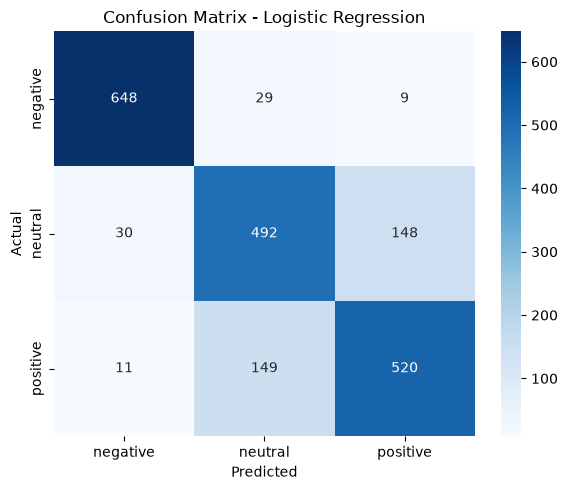

In [10]:
plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues',

    xticklabels=model.classes_,

    yticklabels=model.classes_
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix - Logistic Regression")

plt.tight_layout()

plt.savefig(

    "../images/confusion_matrix_baseline.png",

    dpi=300,

    bbox_inches='tight'
)

plt.show()

Test custom sentence

In [11]:
sentence = "Giảng viên dạy rất nhiệt tình"

In [12]:
sentence_vector = vectorizer.transform(
    [sentence]
)

In [13]:
prediction = model.predict(
    sentence_vector
)

In [14]:
print(sentence)

print(prediction[0])

Giảng viên dạy rất nhiệt tình
neutral


Save Baseline model

In [15]:
import joblib

In [16]:
os.makedirs(
    "../models",
    exist_ok=True
)

In [17]:
joblib.dump(

    model,

    "../models/logistic_regression.pkl"
)

['../models/logistic_regression.pkl']

In [18]:
joblib.dump(

    vectorizer,

    "../models/tfidf_vectorizer.pkl"
)

['../models/tfidf_vectorizer.pkl']